In [1]:
import numpy as np                                
import pandas as pd                              
import matplotlib.pyplot as mtp                   
import matplotlib.pyplot as plt                  
import seaborn as sns                             
from sklearn.preprocessing import LabelEncoder    
import io
                                                                                                  
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
CVDRisk = []
CVDRisk = pd.read_csv('CVDRisk_final_ML.csv')
CVDRisk = CVDRisk.drop(columns=['Participant_ID']) 

#Creating list for categorical and numerical variables
cat=[]
cont=[]
for i in CVDRisk.columns:
    if CVDRisk[i].dtype=="object":
        cat.append(i)
    else:
        cont.append(i)
print('Categorical Variables:\n',cat) 
print()
print('Numeric Variables:\n',cont)

Categorical Variables:
 ['Sex', 'Smoking_Status_Qrisk3_1', 'Ethnicity', 'CKD', 'AF', 'Migraine', 'SLE', 'DMT1', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med', 'CVD_Outcome']

Numeric Variables:
 ['Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio']


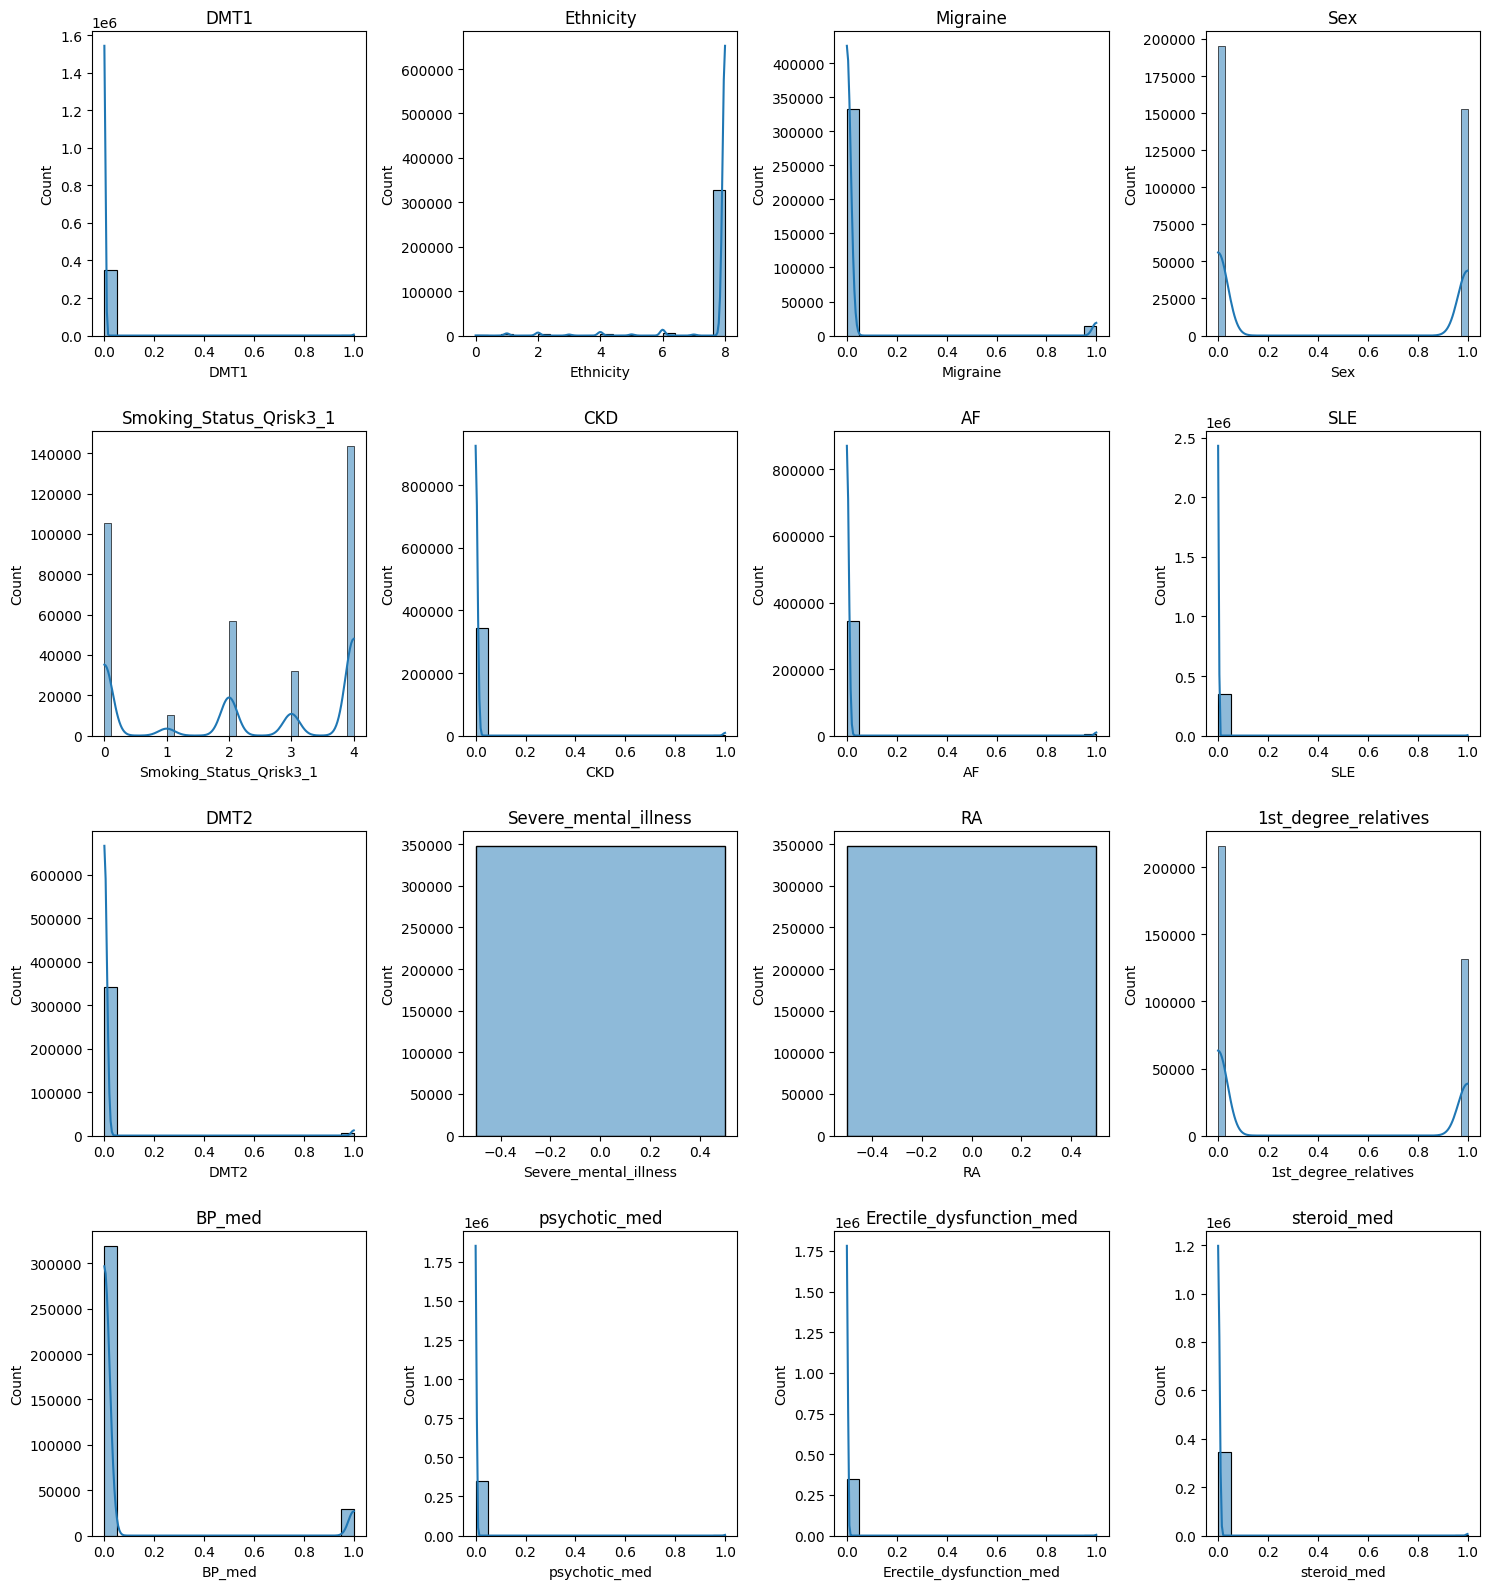

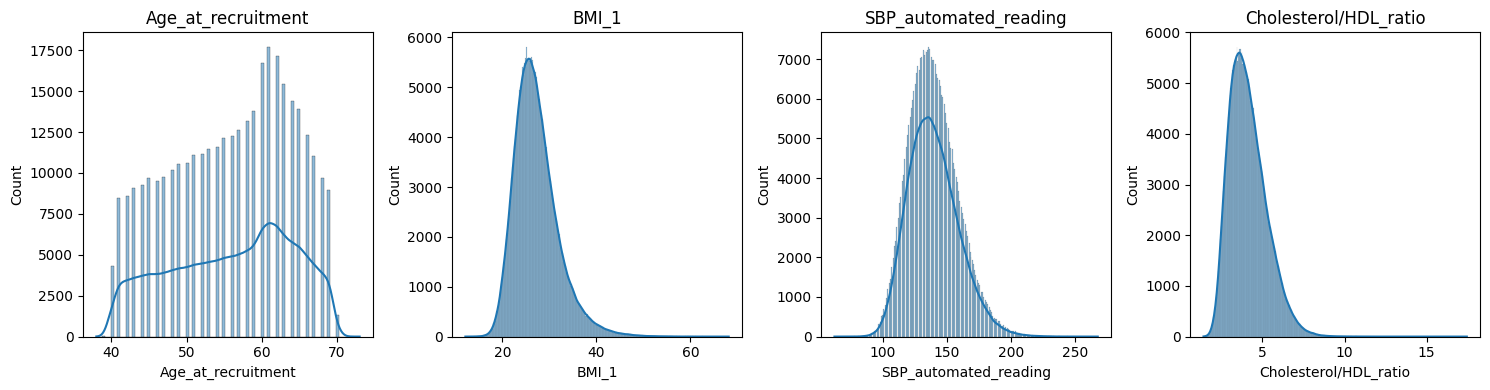

In [3]:
# Define the target variable
target_variable = 'CVD_Outcome' 

# Define the feature variables
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine','Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    CVDRisk.drop(columns=[target_variable]), 
    CVDRisk[target_variable], 
    test_size=0.2, random_state=42
)

# Preprocessing: Standardize numeric variables
scaler = StandardScaler()
X_train[numeric_variables] = scaler.fit_transform(X_train[numeric_variables])
X_test[numeric_variables] = scaler.transform(X_test[numeric_variables])

# Define a function to evaluate model performance
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, precision, recall, f1

# Define a function to plot feature distributions
def plot_feature_distributions(CVDRisk, features):
    num_features = len(features)
    num_subplots = min(num_features, 16)  # Limit the number of subplots to 16
    num_rows = (num_subplots - 1) // 4 + 1
    num_cols = min(num_subplots, 4)
    
    plt.figure(figsize=(15, 4 * num_rows))
    for i, feature in enumerate(features[:num_subplots], 1):
        plt.subplot(num_rows, num_cols, i)
        sns.histplot(CVDRisk[feature], kde=True)
        plt.title(feature)
    plt.tight_layout()
    plt.show()


    
# Plot distributions of categorical variables
plot_feature_distributions(CVDRisk, categorical_variables)

# Plot distributions of numeric variables
plot_feature_distributions(CVDRisk, numeric_variables)

Gradient Boosting Classifier Results:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.41      0.00      0.00      4626

    accuracy                           0.93     69603
   macro avg       0.67      0.50      0.48     69603
weighted avg       0.90      0.93      0.90     69603

Gradient Boosting Results:
Accuracy: 0.9335
Precision: 0.4091
Recall: 0.0019
F1-score: 0.0039
Precision: 0.6714
Recall: 0.5009
F1-score: 0.4847


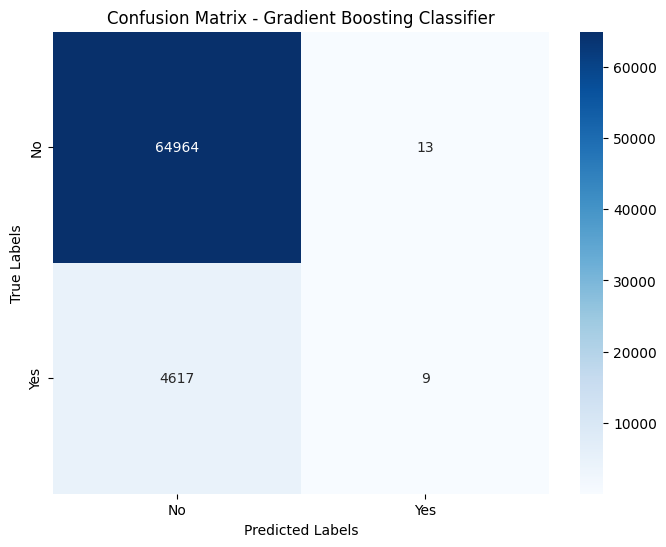

Gradient Boosting Classifier AUC: 0.7253


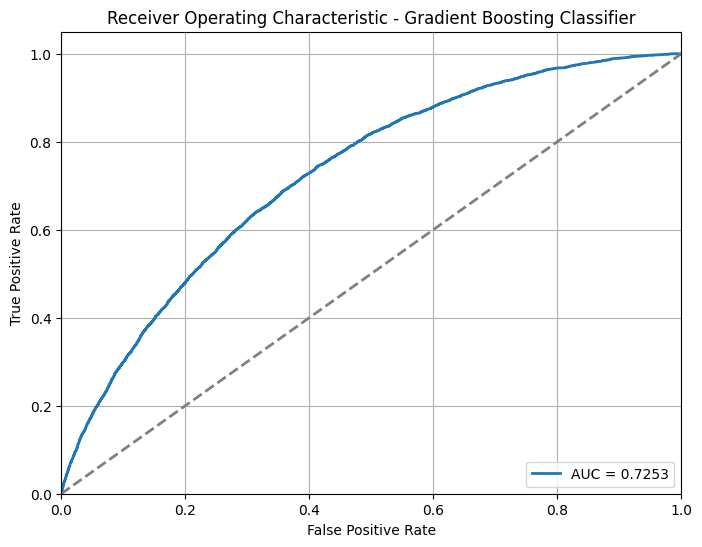

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Initialize the Gradient Boosting classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the model
gb_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_classifier.predict(X_test)

# Predict probabilities on the test set and select the probabilities for the positive class
y_prob_gb = gb_classifier.predict_proba(X_test)[:, 1]

# Evaluate model performance
classification_rep_gb = classification_report(y_test, y_pred_gb, target_names=['no', 'yes'], zero_division=1)

# Display classification report
print("Gradient Boosting Classifier Results:")
print(classification_rep_gb)

# Evaluate model performance
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
precision_gb_macro = precision_score(y_test, y_pred_gb, average='macro')
recall_gb_macro = recall_score(y_test, y_pred_gb, average='macro')
f1_gb_macro = f1_score(y_test, y_pred_gb, average='macro')

# Display results
print("Gradient Boosting Results:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")
print(f"Precision: {precision_gb_macro:.4f}")
print(f"Recall: {recall_gb_macro:.4f}")
print(f"F1-score: {f1_gb_macro:.4f}")

# Generate confusion matrix for Gradient Boosting Classifier
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.show()

# ROC Analysis
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)

# Calculate AUC
auc_gb = roc_auc_score(y_test, y_prob_gb)
print(f"Gradient Boosting Classifier AUC: {auc_gb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc_gb:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Gradient Boosting Classifier')
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

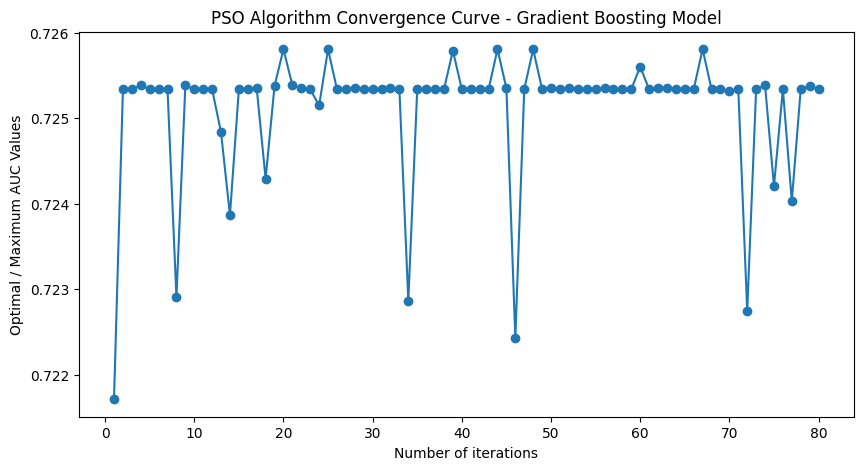

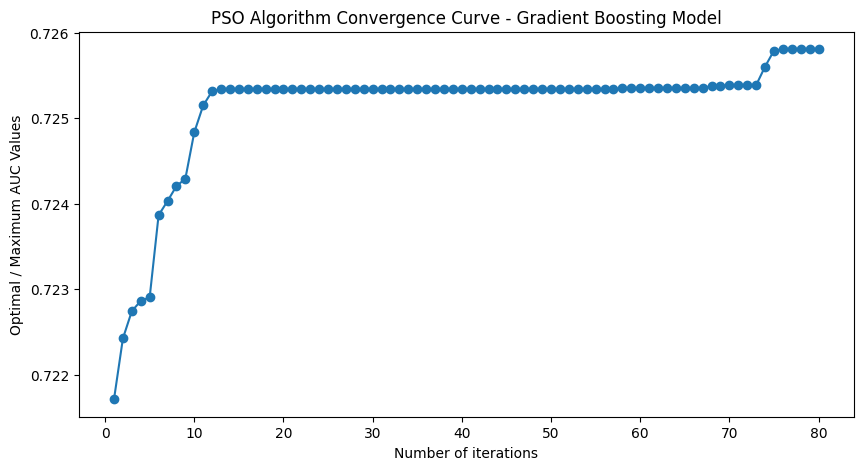

AUC after PSO (using selected features): 0.7258


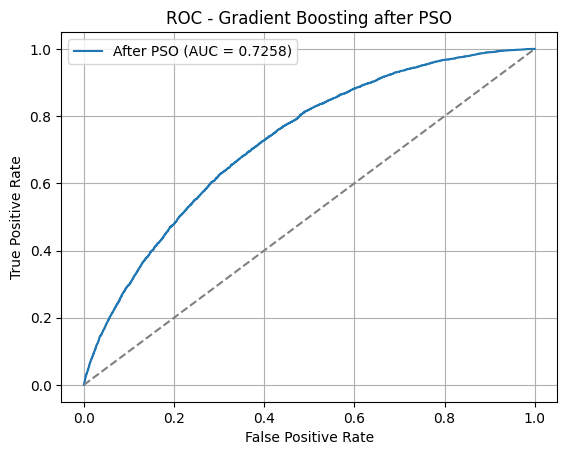

Best AUC: 0.7258
Best Features: [13, 1, 6, 8, 4, 15, 7, 10, 3, 18, 5, 9, 17, 2, 19, 12, 16, 0]
Feature Names: ['Severe_mental_illness', 'Sex', 'Ethnicity', 'AF', 'Cholesterol/HDL_ratio', '1st_degree_relatives', 'CKD', 'SLE', 'SBP_automated_reading', 'Erectile_dysfunction_med', 'Smoking_Status_Qrisk3_1', 'Migraine', 'psychotic_med', 'BMI_1', 'steroid_med', 'DMT2', 'BP_med', 'Age_at_recruitment']
Gradient Boosting Classifier Results with PSO Feature Selection:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.33      0.00      0.00      4626

    accuracy                           0.93     69603
   macro avg       0.63      0.50      0.48     69603
weighted avg       0.89      0.93      0.90     69603

Accuracy: 0.9335
Precision: 0.6335
Recall: 0.5005
F1-score: 0.4839


NameError: name 'precision_best_macro' is not defined

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = GradientBoostingClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Gradient Boosting Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Gradient Boosting Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()


# Get the best features data
best_features_data = X.iloc[:, best_features].values
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the Gradient Boosting model using the best features
best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_gb = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_gb = roc_auc_score(y_test_best, y_pred_prob_best_gb)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_gb:.4f}")

# ROC Analysis
fpr_best_gb, tpr_best_gb, _ = roc_curve(y_test_best, y_pred_prob_best_gb)

plt.figure()
plt.plot(fpr_best_gb, tpr_best_gb, label=f'After PSO (AUC = {auc_after_pso_gb:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Gradient Boosting after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Gradient Boosting Classifier Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best, average='macro', zero_division=1)
recall_best = recall_score(y_test_best, y_pred_best, average='macro')
f1_best = f1_score(y_test_best, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best, recall_best, f1_best]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Gradient Boosting Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Gradient Boosting Classifier with PSO Feature Selection')
plt.show()


# Analyze characteristics based on prediction groups
# Add predictions to X_test_best
X_test_best = pd.DataFrame(X_test_best, columns=X.columns[best_features])
X_test_best['prediction'] = y_pred_best

# Combine X_test_best and y_test_best for complete dataset
test_data = X_test_best.copy()
test_data['CVD_Outcome'] = y_test_best

# Function to calculate counts and percentages
def calculate_counts_and_percentages(df, group_col, count_col):
    counts = df.groupby(group_col)[count_col].value_counts().unstack(fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    return counts, percentages

# List of characteristics to analyze
characteristics = ['Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'DMT1', 'DMT2', 'Ethnicity', 'AF', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med']

# Create a summary table for each characteristic
summary_tables = {}
for characteristic in characteristics:
    if characteristic in test_data.columns:
        counts, percentages = calculate_counts_and_percentages(test_data, 'prediction', characteristic)
        summary_tables[characteristic] = (counts, percentages)

# Display the summary tables
for characteristic, (counts, percentages) in summary_tables.items():
    print(f"\nCount for '{characteristic}' based on prediction:")
    print(counts)
    print(f"\nPercentage for '{characteristic}' based on prediction:")
    print(percentages)


Accuracy: 0.9335
Precision: 0.6335
Recall: 0.5005
F1-score: 0.4839
Precision: 0.6335
Recall: 0.5005
F1-score: 0.4839


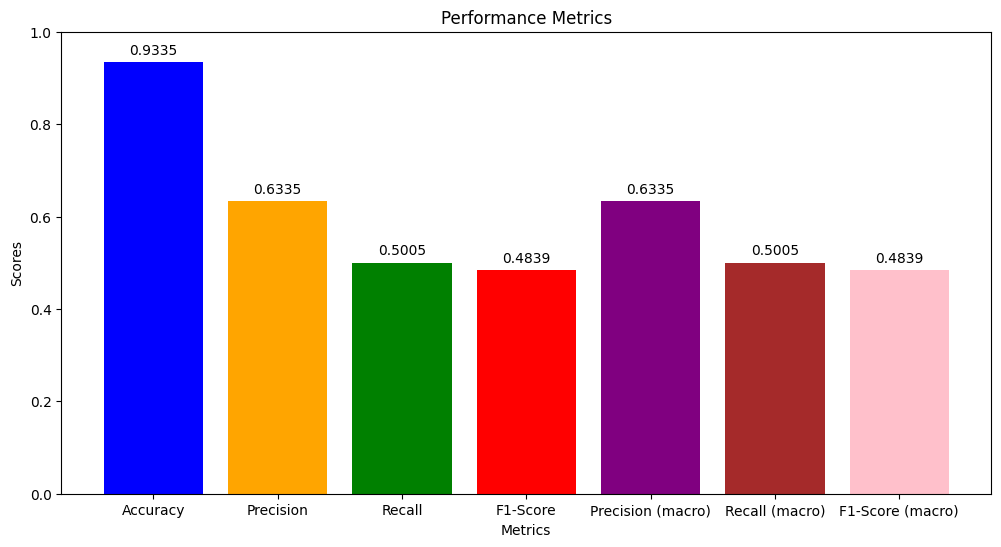

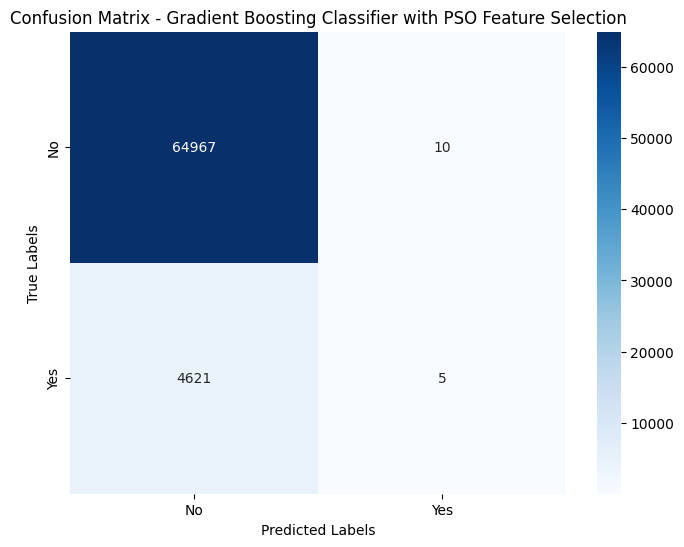


Count for 'Sex' based on prediction:
Sex           0.0    1.0
prediction              
0           38953  30635
1               1     14

Percentage for 'Sex' based on prediction:
Sex               0.0        1.0
prediction                      
0           55.976605  44.023395
1            6.666667  93.333333

Count for 'Smoking_Status_Qrisk3_1' based on prediction:
Smoking_Status_Qrisk3_1    0.0   1.0    2.0   3.0    4.0
prediction                                              
0                        21098  2101  11261  6433  28695
1                            3     2      2     3      5

Percentage for 'Smoking_Status_Qrisk3_1' based on prediction:
Smoking_Status_Qrisk3_1        0.0        1.0        2.0       3.0        4.0
prediction                                                                   
0                        30.318446   3.019199  16.182388   9.24441  41.235558
1                        20.000000  13.333333  13.333333  20.00000  33.333333

Count for 'CKD' based on 

In [7]:

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best, recall_best, f1_best]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Gradient Boosting Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Gradient Boosting Classifier with PSO Feature Selection')
plt.show()


# Analyze characteristics based on prediction groups
# Add predictions to X_test_best
X_test_best = pd.DataFrame(X_test_best, columns=X.columns[best_features])
X_test_best['prediction'] = y_pred_best

# Combine X_test_best and y_test_best for complete dataset
test_data = X_test_best.copy()
test_data['CVD_Outcome'] = y_test_best

# Function to calculate counts and percentages
def calculate_counts_and_percentages(df, group_col, count_col):
    counts = df.groupby(group_col)[count_col].value_counts().unstack(fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    return counts, percentages

# List of characteristics to analyze
characteristics = ['Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'DMT1', 'DMT2', 'Ethnicity', 'AF', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med']

# Create a summary table for each characteristic
summary_tables = {}
for characteristic in characteristics:
    if characteristic in test_data.columns:
        counts, percentages = calculate_counts_and_percentages(test_data, 'prediction', characteristic)
        summary_tables[characteristic] = (counts, percentages)

# Display the summary tables
for characteristic, (counts, percentages) in summary_tables.items():
    print(f"\nCount for '{characteristic}' based on prediction:")
    print(counts)
    print(f"\nPercentage for '{characteristic}' based on prediction:")
    print(percentages)


### characteristics of the prediction for numerical and categorical features

In [9]:
# Analyze characteristics based on prediction groups
# Add predictions to X_test_best
X_test_best = pd.DataFrame(X_test_best, columns=X.columns[best_features])
X_test_best['prediction'] = y_pred_best

# Combine X_test_best and y_test_best for complete dataset
test_data = X_test_best.copy()
test_data['CVD_Outcome'] = y_test_best

# Function to calculate counts and percentages
def calculate_counts_and_percentages(df, group_col, count_col):
    counts = df.groupby(group_col)[count_col].value_counts().unstack(fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    return counts, percentages

# List of characteristics to analyze
characteristics = ['Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'DMT1', 'DMT2', 'Ethnicity', 'AF', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med']

# Create a summary table for each characteristic
summary_tables = {}
for characteristic in characteristics:
    if characteristic in test_data.columns:
        counts, percentages = calculate_counts_and_percentages(test_data, 'prediction', characteristic)
        summary_tables[characteristic] = (counts, percentages)

# Display the summary tables
for characteristic, (counts, percentages) in summary_tables.items():
    print(f"\nCount for '{characteristic}' based on prediction:")
    print(counts)
    print(f"\nPercentage for '{characteristic}' based on prediction:")
    print(percentages)

# Function to calculate medians and 95% confidence intervals using bootstrapping
def calculate_median_ci(df, group_col, num_col, n_bootstraps=1000):
    grouped = df.groupby(group_col)[num_col]
    medians = grouped.median()
    ci_lower = {}
    ci_upper = {}
    
    for name, group in grouped:
        bootstrap_samples = np.random.choice(group, (n_bootstraps, len(group)), replace=True)
        bootstrap_medians = np.median(bootstrap_samples, axis=1)
        ci_lower[name] = np.percentile(bootstrap_medians, 2.5)
        ci_upper[name] = np.percentile(bootstrap_medians, 97.5)
    
    ci_df = pd.DataFrame({'Median': medians, 'CI Lower 95%': ci_lower, 'CI Upper 95%': ci_upper})
    return ci_df

# Create a summary table for each numeric variable with 95% confidence intervals
numeric_summaries = {}
for numeric_variable in numeric_variables:
    summary = calculate_median_ci(test_data, 'prediction', numeric_variable)
    numeric_summaries[numeric_variable] = summary

# Display the numeric summaries
for numeric_variable, summary in numeric_summaries.items():
    print(f"\nSummary for '{numeric_variable}' based on prediction:")
    print(summary)


Count for 'Sex' based on prediction:
Sex           0.0    1.0
prediction              
0           38953  30635
1               1     14

Percentage for 'Sex' based on prediction:
Sex               0.0        1.0
prediction                      
0           55.976605  44.023395
1            6.666667  93.333333

Count for 'Smoking_Status_Qrisk3_1' based on prediction:
Smoking_Status_Qrisk3_1    0.0   1.0    2.0   3.0    4.0
prediction                                              
0                        21098  2101  11261  6433  28695
1                            3     2      2     3      5

Percentage for 'Smoking_Status_Qrisk3_1' based on prediction:
Smoking_Status_Qrisk3_1        0.0        1.0        2.0       3.0        4.0
prediction                                                                   
0                        30.318446   3.019199  16.182388   9.24441  41.235558
1                        20.000000  13.333333  13.333333  20.00000  33.333333

Count for 'CKD' based on 

#### Characteristics of the training set and test set of the Gradient Boosting + PSO

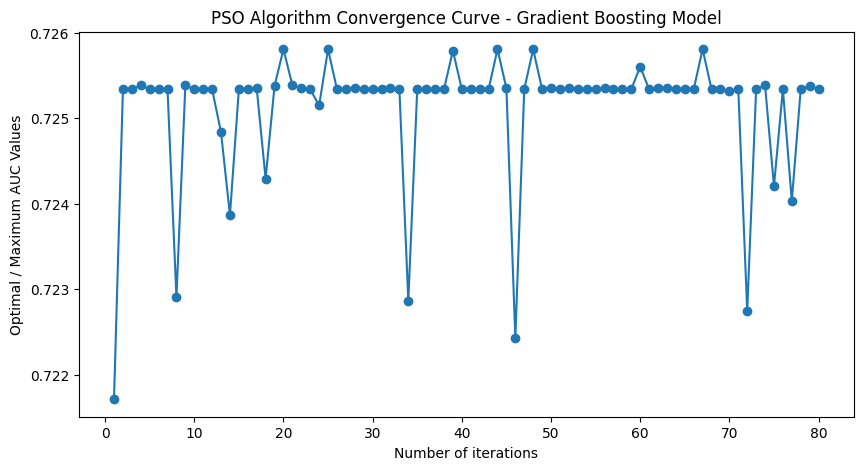

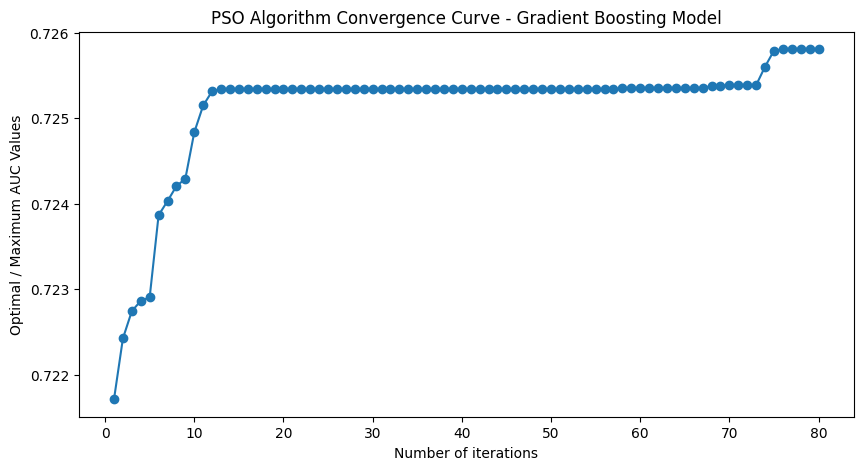

AUC after PSO (using selected features): 0.7258


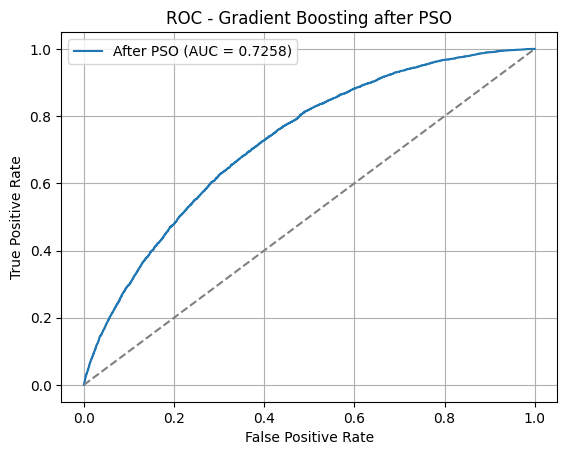

Best AUC: 0.7258
Best Features: [13, 1, 6, 8, 4, 15, 7, 10, 3, 18, 5, 9, 17, 2, 19, 12, 16, 0]
Feature Names: ['Severe_mental_illness', 'Sex', 'Ethnicity', 'AF', 'Cholesterol/HDL_ratio', '1st_degree_relatives', 'CKD', 'SLE', 'SBP_automated_reading', 'Erectile_dysfunction_med', 'Smoking_Status_Qrisk3_1', 'Migraine', 'psychotic_med', 'BMI_1', 'steroid_med', 'DMT2', 'BP_med', 'Age_at_recruitment']
Gradient Boosting Classifier Results with PSO Feature Selection:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.33      0.00      0.00      4626

    accuracy                           0.93     69603
   macro avg       0.63      0.50      0.48     69603
weighted avg       0.89      0.93      0.90     69603

Accuracy: 0.9335
Precision: 0.3333
Recall: 0.0011
F1-score: 0.0022
Precision (macro): 0.6335
Recall (macro): 0.5005
F1-score (macro): 0.4839


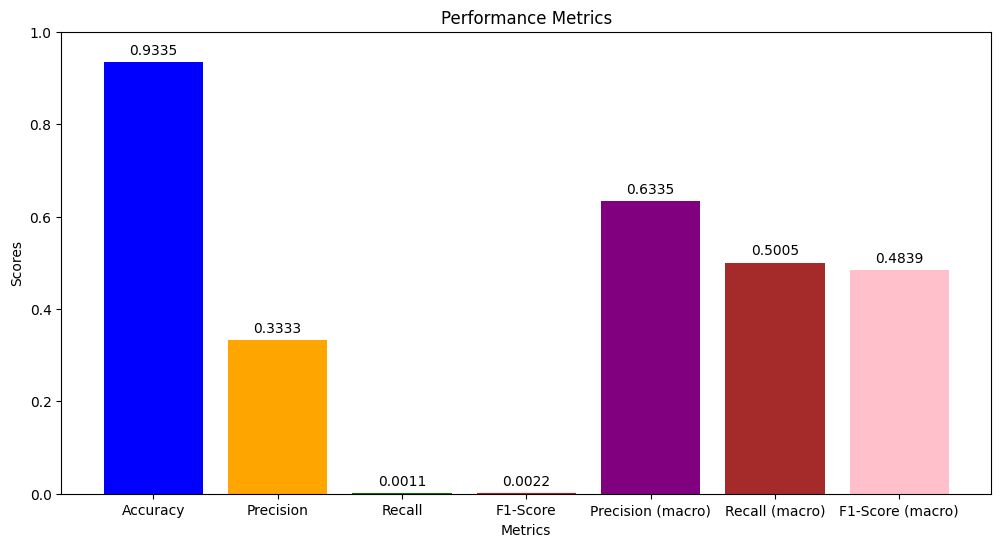

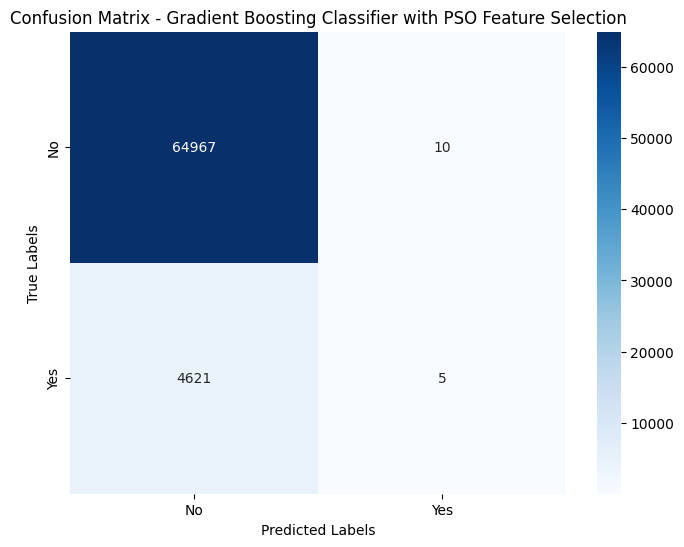

Training Set Characteristics:

Count for 'Sex' based on training set:
Sex               0       1
CVD_Outcome                
0            149096  110806
1              7349   11161

Percentage for 'Sex' based on training set:
Sex                  0          1
CVD_Outcome                      
0            57.366238  42.633762
1            39.702863  60.297137

Count for 'Smoking_Status_Qrisk3_1' based on training set:
Smoking_Status_Qrisk3_1      0     1      2      3       4
CVD_Outcome                                               
0                        79174  7099  41967  23294  108368
1                         5008  1076   3353   2500    6573

Percentage for 'Smoking_Status_Qrisk3_1' based on training set:
Smoking_Status_Qrisk3_1          0         1          2          3          4
CVD_Outcome                                                                  
0                        30.463021  2.731414  16.147240   8.962609  41.695716
1                        27.055646  5.8130

KeyError: 'CVD_Outcome'

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = GradientBoostingClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Gradient Boosting Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Gradient Boosting Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Get the best features data
best_features_data = X.iloc[:, best_features]
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the Gradient Boosting model using the best features
best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_gb = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_gb = roc_auc_score(y_test_best, y_pred_prob_best_gb)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_gb:.4f}")

# ROC Analysis
fpr_best_gb, tpr_best_gb, _ = roc_curve(y_test_best, y_pred_prob_best_gb)

plt.figure()
plt.plot(fpr_best_gb, tpr_best_gb, label=f'After PSO (AUC = {auc_after_pso_gb:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Gradient Boosting after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Gradient Boosting Classifier Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best_macro = precision_score(y_test_best, y_pred_best, average='macro', zero_division=1)
recall_best_macro = recall_score(y_test_best, y_pred_best, average='macro')
f1_best_macro = f1_score(y_test_best, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision (macro): {precision_best_macro:.4f}")
print(f"Recall (macro): {recall_best_macro:.4f}")
print(f"F1-score (macro): {f1_best_macro:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best_macro, recall_best_macro, f1_best_macro]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Gradient Boosting Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Gradient Boosting Classifier with PSO Feature Selection')
plt.show()

# Function to calculate counts and percentages
def calculate_counts_and_percentages(df, group_col, count_col):
    counts = df.groupby(group_col)[count_col].value_counts().unstack(fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    return counts, percentages

# Analyze characteristics based on prediction groups
def analyze_characteristics(X_train, y_train, X_test, y_test, categorical_variables):
    train_data = pd.DataFrame(X_train, columns=X.columns[best_features])
    train_data['CVD_Outcome'] = y_train
    test_data = pd.DataFrame(X_test, columns=X.columns[best_features])
    test_data['CVD_Outcome'] = y_test
    
    # Calculate counts and percentages for training set
    print("Training Set Characteristics:")
    for characteristic in categorical_variables:
        if characteristic in train_data.columns:
            counts, percentages = calculate_counts_and_percentages(train_data, 'CVD_Outcome', characteristic)
            print(f"\nCount for '{characteristic}' based on training set:")
            print(counts)
            print(f"\nPercentage for '{characteristic}' based on training set:")
            print(percentages)
    
    # Calculate counts and percentages for test set
    print("\nTest Set Characteristics:")
    for characteristic in categorical_variables:
        if characteristic in test_data.columns:
            counts, percentages = calculate_counts_and_percentages(test_data, 'CVD_Outcome', characteristic)
            print(f"\nCount for '{characteristic}' based on test set:")
            print(counts)
            print(f"\nPercentage for '{characteristic}' based on test set:")
            print(percentages)

# List of characteristics to analyze
characteristics = ['Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'DMT1', 'DMT2', 'Ethnicity', 'AF', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med']

# Call the function to analyze characteristics of the training and test sets
analyze_characteristics(X_train_best, y_train_best, X_test_best, y_test_best, characteristics)

# Calculate statistics for numeric variables
def calculate_numeric_statistics(df, group_col, numeric_vars):
    statistics = {}
    for var in numeric_vars:
        group_stats = df.groupby(group_col)[var].describe(percentiles=[.025, .5, .975])
        group_stats = group_stats[['50%', '2.5%', '97.5%']]
        group_stats.columns = ['Median', 'CI Lower 95%', 'CI Upper 95%']
        statistics[var] = group_stats
    return statistics

# Get numeric statistics for training set
train_numeric_stats = calculate_numeric_statistics(pd.DataFrame(X_train_best, columns=X.columns[best_features]), 'CVD_Outcome', numeric_variables)

# Get numeric statistics for test set
test_numeric_stats = calculate_numeric_statistics(pd.DataFrame(X_test_best, columns=X.columns[best_features]), 'CVD_Outcome', numeric_variables)

# Display numeric statistics
print("\nTraining Set Numeric Statistics:")
for var, stats in train_numeric_stats.items():
    print(f"\nSummary for '{var}' based on CVD_Outcome:")
    print(stats)

print("\nTest Set Numeric Statistics:")
for var, stats in test_numeric_stats.items():
    print(f"\nSummary for '{var}' based on CVD_Outcome:")
    print(stats)
